# Regression Trees

## Import Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.tree import DecisionTreeRegressor

In [2]:
root_path = Path(".").absolute()
data_path = root_path / "data"
data_path.mkdir(exist_ok=True)

%matplotlib inline

## Dataset Analysis

<p>In this section you will read the dataset in a Pandas dataframe and visualize its content. You will also look at some data statistics.</p>
<p>Note: A Pandas dataframe is a two-dimensional, size-mutable, potentially heterogeneous tabular data structure. Click <a href="https://pandas.pydata.org/pandas-docs/version/2.3/reference/api/pandas.DataFrame.html">here</a> for more information.</p>

In [3]:
# url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv'
file = data_path / "yellow_tripdata.csv"
raw_data = pd.read_csv(file)
raw_data

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41197,2,1,16.94,2,1,132,164,1,70.0,0.5,6.94,1,5.00
41198,2,4,19.83,2,1,132,166,1,70.0,0.5,6.94,1,8.00
41199,2,1,17.31,2,1,132,137,1,70.0,0.5,6.94,1,8.00
41200,2,1,17.28,2,1,132,233,1,70.0,0.5,6.94,1,16.19


<p>Each row in the dataset represents a taxi trip. As shown above, each row has 13 variables. One of the variables is <code>tip_amount</code> which will be the target variable. Your objective will be to train a model that uses the other variables to predict the value of the <code>tip_amount</code> variable.</p>
<p>To understand the dataset a little better, let us plot the correlation of the target variable against the input variables.</p>

<Axes: >

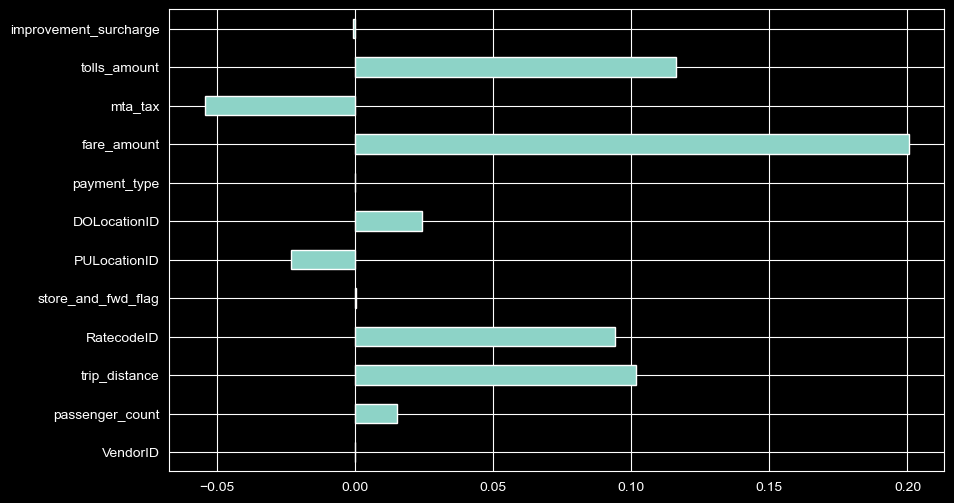

In [4]:
correlation_values = raw_data.corr()["tip_amount"].drop("tip_amount")
correlation_values.plot(kind="barh", figsize=(10, 6))

<p>This shows us that the input features <code>payment_type</code>, <code>VendorID</code>, <code>store_and_fwd_flag</code> and <code>improvement_surcharge</code> have little to no correlation with the target variable.</p>

## Dataset Preprocessing

<p>You will now prepare the data for training by applying normalization to the input features.</p>

In [5]:
y = raw_data.loc[:, ["tip_amount"]].values.astype("float32")

proc_data = raw_data.drop(["tip_amount"], axis=1)
X = proc_data.values
X = normalize(X, axis=1, norm="l1", copy=False)

## Dataset Train/Test Split

<p>Now that the dataset is ready for building the classification models, you need to first divide the preprocessed dataset into a subset to be used for training the model (the train set) and a subset to be used for evaluating the quality of the model (the test set).</p>

In [6]:
split_data: list[np.ndarray] = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = split_data

## Build a Decision Tree Regressor model with `scikit-learn`

<p>Regression Trees are implemented using <code>DecisionTreeRegressor</code>. The important parameters of the model are:</p>
<ul>
    <li><code>criterion</code>: The function used to measure error, we use "squared_error".</li>
    <li><code>max_depth</code>: The maximum depth the tree is allowed to take, we use 8.</li>
</ul>

In [7]:
dt_reg = DecisionTreeRegressor(criterion="squared_error", max_depth=8, random_state=35)

<p>Now lets train our model using the <code>fit</code> method on the <code>DecisionTreeRegressor</code> object providing our training data.</p>

In [8]:
dt_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=35)

## Evaluate the `scikit-learn` and Snap ML Decision Tree Regressor Models

<p>To evaluate our dataset, we will use the <code>score</code> method of the <code>DecisionTreeRegressor</code> object providing our testing data, this number is the R<sup>2</sup> value which indicates the coefficient of determination. We will also evaluate the Mean Squared Error (MSE) of the regression output with respect to the test set target values. High R<sup>2</sup> and low MSE values are expected from a good regression model.</p>

In [9]:
y_pred = dt_reg.predict(X_test)

mse_score = mean_squared_error(y_test, y_pred)
print(f"MSE score: {mse_score:.3f}")

r2_score = dt_reg.score(X_test, y_test)
print(f"R2 score: {r2_score:.3f}")

MSE score: 24.555
R2 score: 0.028


## Practice

<p>1. Identify the top 3 features with the most effect on the <code>tip_amount</code>.</p>

In [10]:
correlation_values_practice = raw_data.corr()["tip_amount"].drop("tip_amount")
abs(correlation_values_practice).sort_values(ascending=False)[: 3]

fare_amount      0.200638
tolls_amount     0.116172
trip_distance    0.101819
Name: tip_amount, dtype: float64

<p>2. Since we identified 4 features which are not correlated with the target variable, try removing these variables from the input set and see the effect on the MSE and R<sup>2</sup> value.</p>

In [11]:
raw_data = raw_data.drop(["payment_type", "VendorID", "store_and_fwd_flag", "improvement_surcharge"], axis=1)
raw_data

,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,fare_amount,mta_tax,tolls_amount,tip_amount
0,1,17.63,2,132,164,70.0,0.5,6.94,16.54
1,1,19.52,2,132,236,70.0,0.5,6.94,16.19
2,1,17.81,2,132,48,70.0,0.5,6.94,12.00
3,2,19.30,2,132,148,70.0,0.5,0.00,5.00
4,1,18.75,2,132,234,70.0,0.5,6.94,10.00
...,...,...,...,...,...,...,...,...,...
41197,1,16.94,2,132,164,70.0,0.5,6.94,5.00
41198,4,19.83,2,132,166,70.0,0.5,6.94,8.00
41199,1,17.31,2,132,137,70.0,0.5,6.94,8.00
41200,1,17.28,2,132,233,70.0,0.5,6.94,16.19


****
This is the end of the file.
****